# Conformal Prediction for Gradient Boosting Models

**Docker image**: `ml4t`

**Chapter 12, Section 12.6**: Uncertainty Quantification with Conformal Prediction

> **GPU recommended**: This notebook trains models with PyTorch/CUDA. It will run on CPU
> but training may be very slow. For GPU acceleration:
> ```bash
> docker compose run --rm ml4t-gpu python 12_gradient_boosting/11_conformal_gbm.py
> ```


## Purpose
This notebook demonstrates **conformal prediction** for uncertainty
quantification with GBMs, providing distribution-free prediction intervals
with guaranteed coverage.

## Learning Objectives
- Implement split conformal prediction from scratch for GBM regression
- Evaluate coverage properties across ETF, crypto, and futures asset classes
- Implement CQR and ACI extensions for non-stationary settings
- Compare split conformal, QR, CQR, and ACI interval behavior
- Apply conformal interval width as a position sizing signal

**Prerequisites**: Requires feature datasets from `case_studies/{etfs,crypto_perps_funding,cme_futures}/features/`.

## Cross-References
- **Section 12.5**: Conformal prediction for UQ, SHAP drift + conformal feedback
- **Chapter 8**: Feature engineering (input data)
- **Chapter 19**: Position sizing with uncertainty
- **Related**: `08_shap_analysis` (drift detection), `09_xai_limitations` (explanation limits)

## 1. Setup

In [1]:
"""Conformal Prediction for GBMs — construct distribution-free prediction intervals for financial forecasts."""

import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from ml4t.diagnostic.metrics import cross_sectional_ic_series

warnings.filterwarnings("ignore")

import lightgbm as lgb

from utils.modeling import load_modeling_dataset
from utils.reproducibility import set_global_seeds
from utils.style import COLORS

In [2]:
MAX_SYMBOLS = 0  # 0 = all symbols
CONFORMAL_ALPHA = 0.10  # 90% prediction intervals
SEED = 42

In [3]:
set_global_seeds(SEED)
CAL_FRACTION = 0.2  # 20% calibration set

## 2. Conformal Prediction Framework

**Split Conformal Prediction** (Vovk et al., 2005; Lei et al., 2018):

Given training data $(X_1, Y_1), \ldots, (X_n, Y_n)$:

1. **Split** into proper training $D_{\text{train}}$ and calibration $D_{\text{cal}}$
2. **Train** model $\hat{f}$ on $D_{\text{train}}$
3. **Compute** residuals $R_i = |Y_i - \hat{f}(X_i)|$ for $(X_i, Y_i) \in D_{\text{cal}}$
4. **Quantile**: $q = \lceil (n_{\text{cal}} + 1)(1 - \alpha) \rceil / n_{\text{cal}}$
5. **Interval**: $C(X_{\text{new}}) = [\hat{f}(X_{\text{new}}) - \hat{q}, \hat{f}(X_{\text{new}}) + \hat{q}]$

**Guarantee**: For exchangeable data, $P(Y_{\text{new}} \in C(X_{\text{new}})) \geq 1 - \alpha$

In [4]:
class ConformalRegressor:
    """Split conformal prediction wrapper for any regression model."""

    def __init__(self, model_factory, alpha: float = 0.10, cal_frac: float = 0.2):
        self.model_factory = model_factory
        self.alpha = alpha
        self.cal_frac = cal_frac
        self.model = None
        self.conformal_width = None
        self.calibration_residuals = None

    def fit(self, X: np.ndarray, y: np.ndarray) -> "ConformalRegressor":
        n_cal = int(len(X) * self.cal_frac)
        n_proper = len(X) - n_cal
        X_proper, X_cal = X[:n_proper], X[n_proper:]
        y_proper, y_cal = y[:n_proper], y[n_proper:]
        self.model = self.model_factory()
        self.model.fit(X_proper, y_proper)
        y_cal_pred = self.model.predict(X_cal)
        residuals = np.abs(y_cal - y_cal_pred)
        self.calibration_residuals = residuals
        n = len(residuals)
        q = np.ceil((n + 1) * (1 - self.alpha)) / n
        self.conformal_width = np.quantile(residuals, min(q, 1.0))
        return self

    def predict(self, X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
        if self.model is None:
            raise ValueError("Model not fitted. Call fit() first.")
        y_pred = self.model.predict(X)
        lower = y_pred - self.conformal_width
        upper = y_pred + self.conformal_width
        return y_pred, lower, upper

    @property
    def interval_width(self) -> float:
        return self.conformal_width

### LightGBM Factory

In [5]:
from sklearn.base import BaseEstimator, RegressorMixin


class LGBWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, n_rounds=200):
        self.n_rounds = n_rounds
        self.model_ = None

    def fit(self, X, y):
        params = {
            "objective": "regression",
            "boosting_type": "gbdt",
            "num_leaves": 31,
            "learning_rate": 0.05,
            "feature_fraction": 0.8,
            "verbose": -1,
            "seed": SEED,
        }
        train_data = lgb.Dataset(X, label=y)
        self.model_ = lgb.train(params, train_data, num_boost_round=self.n_rounds)
        return self

    def predict(self, X):
        return self.model_.predict(X)

### Wrapper Factory

In [6]:
def lgb_model_factory():
    return LGBWrapper(n_rounds=200)

## 3. Load Multi-Asset Data

We compare conformal coverage across three asset classes with
different return distributions and signal-to-noise ratios.

In [7]:
ASSET_CONFIGS = [
    ("etfs", "fwd_ret_21d", "ETF"),
    ("crypto_perps_funding", "fwd_ret_8h", "Crypto"),
    ("cme_futures", "fwd_ret_5d", "Futures"),
]

processed_datasets = {}

for cs_id, label, display_name in ASSET_CONFIGS:
    try:
        mds = load_modeling_dataset(cs_id, label)
        df = mds.dataset.to_pandas()
        date_col = mds.date_col
        feature_cols = mds.feature_names

        split = mds.splits[0]
        mask = (df[date_col] >= split["train_start"]) & (df[date_col] <= split["val_end"])
        subset = df.loc[mask]

        valid = np.isfinite(subset[mds.label_col].values)
        subset = subset.loc[valid]

        if len(subset) > 500:
            entity_col = mds.entity_cols[0]
            processed_datasets[display_name] = {
                "X": subset[feature_cols].values,
                "y": subset[mds.label_col].values,
                "dates": subset[date_col].values,
                "symbols": subset[entity_col].values,
                "feature_cols": feature_cols,
                "n_samples": len(subset),
            }
            print(f"  {display_name}: {len(subset):,} samples ({len(feature_cols)} features)")
    except Exception as e:
        print(f"  {display_name}: skipped ({e})")

print(f"\nLoaded {len(processed_datasets)} asset classes")

  ETF: 253,286 samples (71 features)
  Crypto: 48,867 samples (44 features)


  Futures: 68,539 samples (69 features)

Loaded 3 asset classes


## 4. Conformal Prediction Evaluation

We evaluate conformal prediction on each asset class using
walk-forward validation to test coverage under temporal dependence.

### Walk-Forward Fold Runner

In [8]:
def run_conformal_splits(
    X: np.ndarray,
    y: np.ndarray,
    dates: np.ndarray,
    symbols: np.ndarray,
    alpha: float,
    n_splits: int,
) -> list[dict]:
    n_samples = len(X)
    fold_size = n_samples // (n_splits + 1)
    fold_results = []

    for fold_idx in range(n_splits):
        train_end = fold_size * (fold_idx + 1)
        test_end = min(train_end + fold_size, n_samples)
        if train_end < 200 or (test_end - train_end) < 50:
            continue

        X_train, y_train = X[:train_end], y[:train_end]
        X_test, y_test = X[train_end:test_end], y[train_end:test_end]
        dates_test = dates[train_end:test_end]
        symbols_test = symbols[train_end:test_end]

        conformal = ConformalRegressor(lgb_model_factory, alpha=alpha)
        conformal.fit(X_train, y_train)
        y_pred, lower, upper = conformal.predict(X_test)
        fold_results.append(
            {
                "y_true": y_test,
                "y_pred": y_pred,
                "dates": dates_test,
                "symbols": symbols_test,
                "lower": lower,
                "upper": upper,
                "width": conformal.interval_width,
            }
        )
    return fold_results

### Metric Aggregation

In [9]:
def summarize_conformal_results(results: list[dict], alpha: float) -> dict | None:
    if not results:
        return None

    y_true_all = np.concatenate([r["y_true"] for r in results])
    y_pred_all = np.concatenate([r["y_pred"] for r in results])
    dates_all = np.concatenate([r["dates"] for r in results])
    symbols_all = np.concatenate([r["symbols"] for r in results])
    lower_all = np.concatenate([r["lower"] for r in results])
    upper_all = np.concatenate([r["upper"] for r in results])

    in_interval = (y_true_all >= lower_all) & (y_true_all <= upper_all)
    coverage = in_interval.mean()

    pred_df = pl.DataFrame(
        {"timestamp": dates_all, "symbol": symbols_all, "prediction": y_pred_all}
    )
    ret_df = pl.DataFrame(
        {"timestamp": dates_all, "symbol": symbols_all, "forward_return": y_true_all}
    )
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    ic = float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")
    avg_width = np.mean(upper_all - lower_all)

    return {
        "coverage": coverage,
        "target_coverage": 1 - alpha,
        "coverage_error": abs(coverage - (1 - alpha)),
        "ic": ic,
        "avg_width": avg_width,
        "n_samples": len(y_true_all),
        "results": results,
    }

### Conformal Evaluation Wrapper

In [10]:
def evaluate_conformal(
    X: np.ndarray,
    y: np.ndarray,
    dates: np.ndarray,
    symbols: np.ndarray,
    alpha: float = 0.10,
    n_splits: int = 5,
) -> dict | None:
    results = run_conformal_splits(X, y, dates, symbols, alpha=alpha, n_splits=n_splits)
    return summarize_conformal_results(results, alpha)

In [11]:
all_metrics = {}

for asset_name, data in processed_datasets.items():
    metrics = evaluate_conformal(
        data["X"],
        data["y"],
        data["dates"],
        data["symbols"],
        alpha=CONFORMAL_ALPHA,
        n_splits=5,
    )
    if metrics:
        all_metrics[asset_name] = metrics

In [12]:
eval_df = pl.DataFrame(
    [
        {
            "symbol": name,
            "coverage": round(m["coverage"], 3),
            "target": round(m["target_coverage"], 2),
            "coverage_error": round(m["coverage_error"], 3),
            "IC": round(m["ic"], 3),
            "interval_width": round(m["avg_width"], 5),
            "n_samples": m["n_samples"],
        }
        for name, m in all_metrics.items()
    ]
)
eval_df

symbol,coverage,target,coverage_error,IC,interval_width,n_samples
str,f64,f64,f64,f64,f64,i64
"""ETF""",0.886,0.9,0.014,0.211,0.14521,211070
"""Crypto""",0.897,0.9,0.003,0.01,0.09946,40720
"""Futures""",0.827,0.9,0.073,0.049,0.09701,57115


**Interpretation**: Split conformal lands close to the 0.90 target across all
three asset classes — Crypto at 0.897 and ETF at 0.886 are within ~1.5 pp, and
Futures shows the largest shortfall at 0.827 (about 7 pp under). The
finite-sample guarantee assumes exchangeability between calibration and test
residuals; under walk-forward evaluation that assumption holds only
approximately, so coverage drifts modestly below nominal where the residual
distribution shifts faster than the calibration set can track — most visibly on
Futures here. Section 6 compares CQR and ACI variants, which adapt interval shape
to local volatility rather than applying one global residual quantile.

## 5. Coverage Visualization

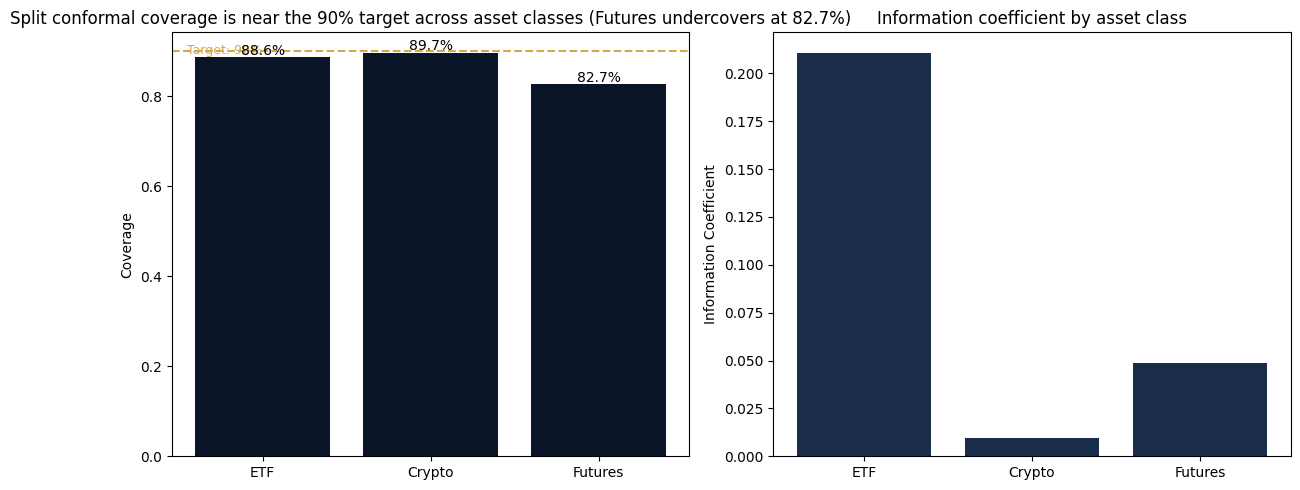

In [13]:
if all_metrics:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    assets = list(all_metrics.keys())
    coverages = [all_metrics[a]["coverage"] for a in assets]
    ics = [all_metrics[a]["ic"] for a in assets]

    # Coverage bars
    ax1 = axes[0]
    bars = ax1.bar(assets, coverages, color=COLORS["blue"])
    ax1.axhline(
        1 - CONFORMAL_ALPHA,
        linestyle="--",
        color=COLORS["amber"],
        linewidth=1.5,
    )
    ax1.text(
        -0.45,
        1 - CONFORMAL_ALPHA,
        f"Target: {(1 - CONFORMAL_ALPHA):.0%}",
        color=COLORS["amber"],
        va="center",
        ha="left",
        fontsize=9,
    )
    ax1.set_ylabel("Coverage")
    ax1.set_title(
        "Split conformal coverage is near the 90% target across asset classes (Futures undercovers at 82.7%)"
    )
    for bar, cov in zip(bars, coverages, strict=False):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{cov:.1%}",
            ha="center",
            fontsize=10,
        )

    # IC bars
    ax2 = axes[1]
    ax2.bar(assets, ics, color=COLORS["slate"])
    ax2.set_ylabel("Information Coefficient")
    ax2.set_title("Information coefficient by asset class")

    plt.tight_layout()
    plt.show()

## 6. Conformal Variants: Split, CQR, and Adaptive

| Method | Core Idea | Strength | Limitation |
|--------|-----------|----------|------------|
| **Split Conformal** | Calibrate absolute residuals | Finite-sample coverage | Symmetric intervals |
| **Quantile Regression (QR)** | Learn lower/upper quantiles directly | Asymmetric intervals | No finite-sample guarantee |
| **Conformalized QR (CQR)** | Quantile models + conformal calibration | Asymmetric + calibrated | Needs 2 models + calibration split |
| **Adaptive Conformal (ACI)** | Update miscoverage target online | Tracks regime shifts | Online update hyperparameter sensitivity |

In [14]:
if processed_datasets:
    test_asset = list(processed_datasets.keys())[0]
    test_data = processed_datasets[test_asset]

    n = test_data["n_samples"]
    train_size = int(n * 0.7)

    X_tr = test_data["X"][:train_size]
    y_tr = test_data["y"][:train_size]
    X_te = test_data["X"][train_size:]
    y_te = test_data["y"][train_size:]

    conformal = ConformalRegressor(lgb_model_factory, alpha=CONFORMAL_ALPHA)
    conformal.fit(X_tr, y_tr)
    y_pred_conf, lower_conf, upper_conf = conformal.predict(X_te)

    coverage_conf = ((y_te >= lower_conf) & (y_te <= upper_conf)).mean()
    width_conf = np.mean(upper_conf - lower_conf)

### Train Quantile Regression Models

In [15]:
if processed_datasets:
    lower_q = CONFORMAL_ALPHA / 2
    upper_q = 1 - CONFORMAL_ALPHA / 2
    n_rounds = 200

    train_data = lgb.Dataset(X_tr, label=y_tr)

    model_lower = lgb.train(
        {
            "objective": "quantile",
            "alpha": lower_q,
            "num_leaves": 31,
            "learning_rate": 0.05,
            "verbose": -1,
            "seed": SEED,
        },
        train_data,
        num_boost_round=n_rounds,
    )
    model_upper = lgb.train(
        {
            "objective": "quantile",
            "alpha": upper_q,
            "num_leaves": 31,
            "learning_rate": 0.05,
            "verbose": -1,
            "seed": SEED,
        },
        train_data,
        num_boost_round=n_rounds,
    )

    lower_qr = model_lower.predict(X_te)
    upper_qr = model_upper.predict(X_te)

    coverage_qr = ((y_te >= lower_qr) & (y_te <= upper_qr)).mean()
    width_qr = np.mean(upper_qr - lower_qr)

### Conformalized Quantile Regression (CQR)

$$s_i = \max\left(\hat{q}_{\ell}(x_i) - y_i,\ y_i - \hat{q}_{u}(x_i)\right), \quad
\hat{q}_{\mathrm{cqr}} = Q_{1-\alpha}(s)$$

$$C_{\mathrm{CQR}}(x) = [\hat{q}_{\ell}(x) - \hat{q}_{\mathrm{cqr}},\ \hat{q}_{u}(x) + \hat{q}_{\mathrm{cqr}}]$$

In [16]:
if processed_datasets:
    n_cal = max(50, int(len(X_tr) * CAL_FRACTION))
    X_tr_q, y_tr_q = X_tr[:-n_cal], y_tr[:-n_cal]
    X_cal_q, y_cal_q = X_tr[-n_cal:], y_tr[-n_cal:]

    cqr_train = lgb.Dataset(X_tr_q, label=y_tr_q)
    model_lower_cqr = lgb.train(
        {
            "objective": "quantile",
            "alpha": lower_q,
            "num_leaves": 31,
            "learning_rate": 0.05,
            "verbose": -1,
            "seed": SEED,
        },
        cqr_train,
        num_boost_round=n_rounds,
    )
    model_upper_cqr = lgb.train(
        {
            "objective": "quantile",
            "alpha": upper_q,
            "num_leaves": 31,
            "learning_rate": 0.05,
            "verbose": -1,
            "seed": SEED,
        },
        cqr_train,
        num_boost_round=n_rounds,
    )

    lower_cal = model_lower_cqr.predict(X_cal_q)
    upper_cal = model_upper_cqr.predict(X_cal_q)
    cqr_scores = np.maximum(lower_cal - y_cal_q, y_cal_q - upper_cal)

    cqr_q_level = np.ceil((len(cqr_scores) + 1) * (1 - CONFORMAL_ALPHA)) / len(cqr_scores)
    cqr_qhat = np.quantile(cqr_scores, min(cqr_q_level, 1.0))

In [17]:
if processed_datasets:
    lower_cqr = model_lower_cqr.predict(X_te) - cqr_qhat
    upper_cqr = model_upper_cqr.predict(X_te) + cqr_qhat

    coverage_cqr = ((y_te >= lower_cqr) & (y_te <= upper_cqr)).mean()
    width_cqr = np.mean(upper_cqr - lower_cqr)

### Adaptive Conformal Inference (ACI)

ACI updates the effective miscoverage target online and recomputes interval
width from a rolling residual buffer.

In [18]:
def compute_adaptive_intervals(
    y_pred: np.ndarray,
    y_true: np.ndarray,
    cal_scores: np.ndarray,
    alpha: float = 0.10,
    gamma: float = 0.01,
    window: int = 250,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    scores = list(cal_scores[-window:])
    alpha_t = alpha
    alpha_path = []
    lower = np.empty_like(y_pred)
    upper = np.empty_like(y_pred)

    for i, (pred_i, y_i) in enumerate(zip(y_pred, y_true, strict=False)):
        q_t = np.quantile(scores, 1 - alpha_t)
        lower[i] = pred_i - q_t
        upper[i] = pred_i + q_t

        miss_t = float((y_i < lower[i]) or (y_i > upper[i]))
        alpha_t = float(np.clip(alpha_t + gamma * (alpha - miss_t), 0.01, 0.30))

        scores.append(abs(y_i - pred_i))
        if len(scores) > window:
            scores.pop(0)
        alpha_path.append(alpha_t)

    return lower, upper, np.array(alpha_path)

In [19]:
if processed_datasets:
    lower_aci, upper_aci, alpha_path = compute_adaptive_intervals(
        y_pred_conf,
        y_te,
        conformal.calibration_residuals,
        alpha=CONFORMAL_ALPHA,
        gamma=0.01,
        window=250,
    )
    coverage_aci = ((y_te >= lower_aci) & (y_te <= upper_aci)).mean()
    width_aci = np.mean(upper_aci - lower_aci)

In [20]:
comparison_df = (
    pl.DataFrame(
        {
            "method": [
                "Split Conformal",
                "Quantile Regression",
                "Conformalized Quantile (CQR)",
                "Adaptive Conformal (ACI)",
                "Target",
            ],
            "coverage": [
                round(coverage_conf, 3),
                round(coverage_qr, 3),
                round(coverage_cqr, 3),
                round(coverage_aci, 3),
                round(1 - CONFORMAL_ALPHA, 2),
            ],
            "interval_width": [
                round(width_conf, 5),
                round(width_qr, 5),
                round(width_cqr, 5),
                round(width_aci, 5),
                None,
            ],
        }
    )
    if processed_datasets
    else pl.DataFrame()
)
comparison_df

method,coverage,interval_width
str,f64,f64
"""Split Conformal""",0.905,0.15213
"""Quantile Regression""",0.876,0.13196
"""Conformalized Quantile (CQR)""",0.898,0.1378
"""Adaptive Conformal (ACI)""",0.897,0.14127
"""Target""",0.9,null


In [21]:
# Visualization indices on a shared subsample
if processed_datasets:
    n_show = min(200, len(y_te))
    idx = np.linspace(0, len(y_te) - 1, n_show, dtype=int)
    x_range = np.arange(n_show)

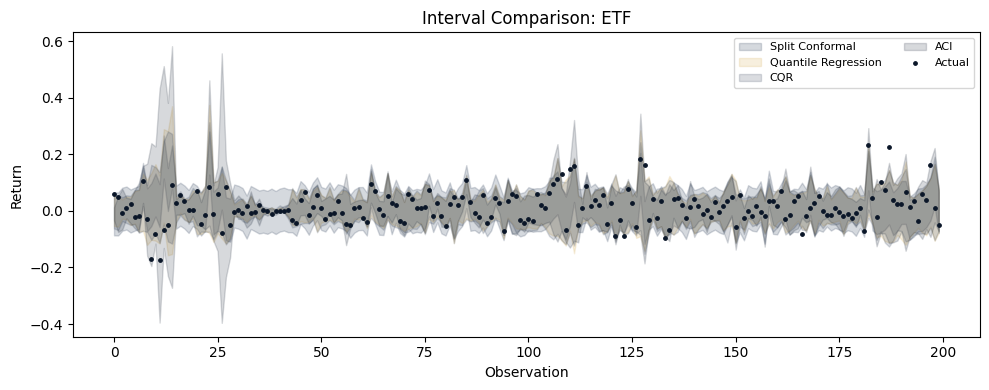

In [22]:
if processed_datasets:
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(
        x_range,
        lower_conf[idx],
        upper_conf[idx],
        alpha=0.18,
        color=COLORS["slate"],
        label="Split Conformal",
    )
    ax.fill_between(
        x_range,
        lower_qr[idx],
        upper_qr[idx],
        alpha=0.18,
        color=COLORS["amber"],
        label="Quantile Regression",
    )
    ax.fill_between(
        x_range, lower_cqr[idx], upper_cqr[idx], alpha=0.18, color=COLORS["neutral"], label="CQR"
    )
    ax.fill_between(
        x_range, lower_aci[idx], upper_aci[idx], alpha=0.16, color=COLORS["blue"], label="ACI"
    )
    ax.scatter(x_range, y_te[idx], s=6, color=COLORS["blue"], zorder=3, label="Actual")
    ax.set_xlabel("Observation")
    ax.set_ylabel("Return")
    ax.set_title(f"Interval Comparison: {test_asset}")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

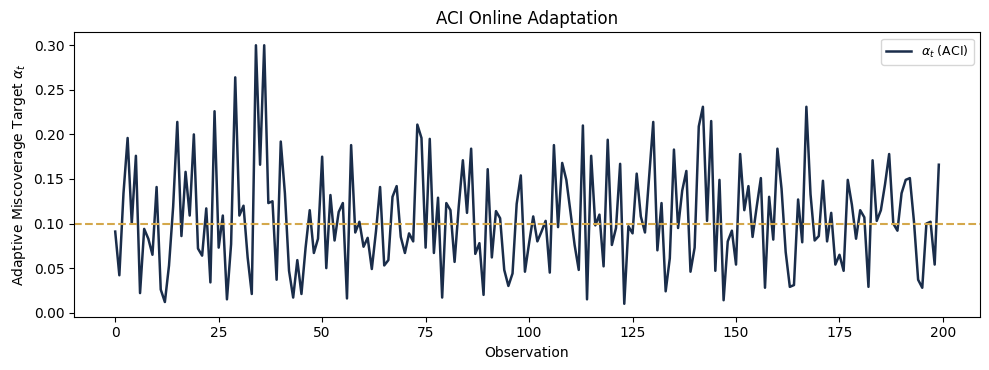

In [23]:
if processed_datasets:
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(alpha_path[idx], color=COLORS["slate"], linewidth=1.8, label=r"$\alpha_t$ (ACI)")
    ax.axhline(CONFORMAL_ALPHA, color=COLORS["amber"], linestyle="--", linewidth=1.5)
    ax.set_xlabel("Observation")
    ax.set_ylabel(r"Adaptive Miscoverage Target $\alpha_t$")
    ax.set_title("ACI Online Adaptation")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

**Interpretation** (numbers from this ETF run):
- Split conformal: coverage 0.905 at width 0.152 — valid but the most
  conservative, applying a single global residual quantile.
- Quantile Regression alone: coverage 0.876 at width 0.132 — the
  narrowest intervals, but slightly below target and with no formal
  guarantee.
- CQR: coverage 0.898 at width 0.138 — conformalizes QR to restore
  calibration while staying narrower than split conformal.
- ACI: coverage 0.897 at width 0.141 — matches target by adapting α_t
  online; useful when residual dynamics are non-stationary.

## 7. Position Sizing Application

Wider intervals signal higher uncertainty, naturally reducing position
size:

$$\text{Position Size} \propto \frac{1}{\text{Interval Width}}$$

In [24]:
if all_metrics:
    example_metrics = list(all_metrics.values())[0]
    widths = [r["width"] for r in example_metrics["results"]]
    mean_width = np.mean(widths)
    position_sizes = [mean_width / w for w in widths]

    sizing_df = pl.DataFrame(
        {
            "fold": list(range(len(widths))),
            "interval_width": [round(w, 5) for w in widths],
            "relative_position": [round(p, 2) for p in position_sizes],
        }
    )
else:
    sizing_df = pl.DataFrame()
sizing_df

fold,interval_width,relative_position
i64,f64,f64
0,0.05901,1.23
1,0.09438,0.77
2,0.06596,1.1
3,0.07469,0.97
4,0.06898,1.05


Narrow intervals (high confidence) scale up positions; wide intervals
(high uncertainty) scale down. This creates a natural risk management
mechanism without explicit regime detection. Chapter 19 integrates
conformal widths into Kelly criterion position sizing.

Combining SHAP drift signals with conformal interval widths creates
a feedback loop: when drift monitoring detects a regime change, the
model's residuals on calibration data grow, widening conformal
intervals and automatically reducing position sizes. See Section 12.5
for the conceptual framework.

## 8. Key Takeaways

1. **Always verify empirical coverage**: Split conformal lands near the
   0.90 target across all three asset classes — Crypto 0.897, ETF 0.886,
   Futures 0.827 — but the shortfall grows where calibration and test
   residuals are less exchangeable (Futures is ~7 pp under). The
   finite-sample bound is only approximate on financial panels under
   temporal dependence, so check empirical coverage rather than assuming
   the guarantee transfers automatically.

2. **The variants trade width for adaptivity, not coverage**: On the ETF
   window, split conformal (0.905), CQR (0.898), and ACI (0.897) all land
   within ±0.01 of the 0.90 target; quantile regression alone slips to
   0.876. The difference is interval width — split conformal is the widest
   (0.152) because it applies one global residual quantile, while CQR
   (0.138) and ACI (0.141) hold coverage with tighter, locally adapted
   intervals.

3. **Distribution-free, model-agnostic**: All four methods work with
   any point-prediction model and require no error-distribution
   assumptions; the trade-off is interval width vs how aggressively
   the method adapts to non-stationary residual dynamics.

4. **Risk management**: Interval width is a natural uncertainty signal
   for position sizing — wider intervals automatically scale positions
   down. Chapter 19 integrates conformal widths into Kelly sizing.

**Next**: See `08_shap_analysis` for SHAP-based drift detection that
complements conformal uncertainty, or Chapter 19 for position sizing.